# ICT-30 — Invention inhibée (expérience E, strate 7)

*Compagnon pédagogique du module `ict.inhibited_invention` (#7746, jambe D2 expérience E — la dernière des cinq).*

Les expériences A à D ont exploré comment une convention *émerge* (A), s'*invente*
(B), se *diffuse* par masse critique (C), devient *endémique* (D) — toutes des
dynamiques **constructives**. Cette expérience E modèle le cas **négatif**, le
revers du décor :

> Que se passe-t-il quand un agent a la **capacité** d'inventer mais **inhibe**
> cette extension de vocabulaire sous l'échec répété ?

C'est le pont vers la strate C2 (#7741, l'animat inhibé de **Henri Laborit**) :
l'**inhibition de l'action** — et ici, de la *re-description / innovation* —
quand l'environnement se révèle incontrôlable.

**Le couplage opposé à B.** L'expérience B couple l'invention à l'erreur de
manière *constructive* : un échec de coordination *déclenche* l'invention d'un
nouveau signal. L'expérience E couple l'invention à l'erreur de manière
*inhibitrice* : chaque échec **accumule** un niveau d'inhibition qui **supprime**
la probabilité d'inventer. Plus l'agent échoue, *moins* il invente — alors même
que l'invention est son seul moyen de sortir du goulot de vocabulaire. C'est le
**paradoxe de Laborit** : l'échec répété dans un environnement incontrôlable
n'augmente pas l'exploration, il la *réduit* (impuissance apprise, **Seligman**
1972 ; inhibition de l'action, **Laborit** 1979).

In [1]:
# Setup : import du package ict (via sys.path cwd, cf C973-L) + numpy/matplotlib.
import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt
from ict import inhibited_invention as ii

print("ict.inhibited_invention chargé.")
print("API publique :", [n for n in dir(ii) if not n.startswith("_")])

ict.inhibited_invention chargé.
API publique : ['Dict', 'InhibitedInventingGame', 'InventingSignalingGame', 'List', 'Optional', 'annotations', 'inhibition_traps_rigidification_test', 'learned_helplessness_test', 'mutual_information', 'no_inhibition_escapes_control_test', 'np', 'trap_persists_under_more_compute_test']


## 1. La rigidification — l'inhibition fige le vocabulaire

Sans inhibition (`inhibition_growth = 0`), l'agent se comporte exactement comme
en B : son vocabulaire croît vers `n_states` (ici 4) et la coordination devient
parfaite. À mesure que l'on augmente la croissance de l'inhibition, le
vocabulaire final **décroît** — l'agent *rigidifie*, figeant un vocabulaire
sous-optimal — et la coordination finale s'effondre avec lui.

On balaie `inhibition_growth` et on observe simultanément le vocabulaire final et
la coordination. Le verdict `rigidification` exige : vocab libre = `n_states`,
vocab au maximum d'inhibition = 1 (totalement figé), et une chute monotone.

Verdict inhibition_traps_rigidification : rigidifies = True
  vocab @inhibition libre (0)   = 4.00
  vocab @inhibition maximale    = 1.00


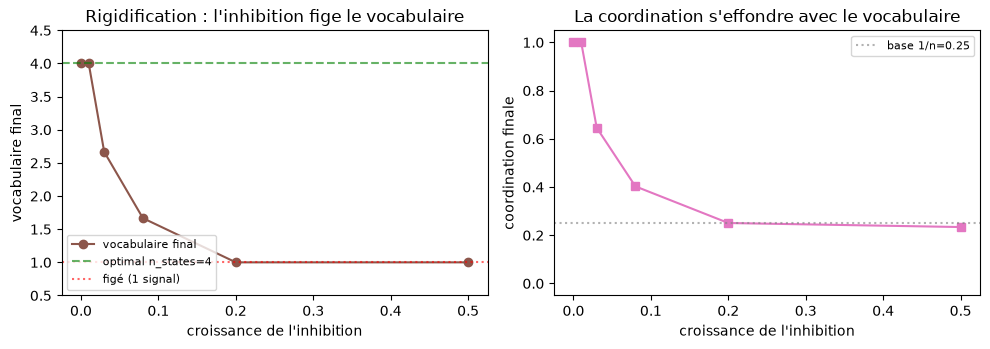

In [2]:
# Verdict RIGIDIFICATION : l'inhibition croissante gele le vocabulaire.
verdict = ii.inhibition_traps_rigidification_test(n_states=4, n_seeds=3, seed=0)
print("Verdict inhibition_traps_rigidification : rigidifies =", bool(verdict["rigidifies"]))
print(f"  vocab @inhibition libre (0)   = {verdict['vocab_at_free_inhibition']:.2f}")
print(f"  vocab @inhibition maximale    = {verdict['vocab_at_max_inhibition']:.2f}")

growths = np.array(verdict["growths"])
vocabs = np.array(verdict["vocab_per_growth"])
coords = np.array(verdict["coord_per_growth"])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(growths, vocabs, "-o", color="#8c564b", label="vocabulaire final")
ax[0].axhline(4, ls="--", color="green", alpha=0.6, label="optimal n_states=4")
ax[0].axhline(1, ls=":", color="red", alpha=0.6, label="figé (1 signal)")
ax[0].set_xlabel("croissance de l'inhibition") ; ax[0].set_ylabel("vocabulaire final")
ax[0].set_title("Rigidification : l'inhibition fige le vocabulaire")
ax[0].set_ylim(0.5, 4.5) ; ax[0].legend(loc="lower left", fontsize=8)
ax[1].plot(growths, coords, "-s", color="#e377c2")
ax[1].axhline(0.25, ls=":", color="grey", alpha=0.6, label="base 1/n=0.25")
ax[1].set_xlabel("croissance de l'inhibition") ; ax[1].set_ylabel("coordination finale")
ax[1].set_title("La coordination s'effondre avec le vocabulaire")
ax[1].set_ylim(-0.05, 1.05) ; ax[1].legend(loc="upper right", fontsize=8)
fig.tight_layout() ; plt.show()

## 2. L'impuissance apprise — l'inhibition plafonne et piège

Avec une inhibition marquée (`growth = 0.08`, sans oubli `decay = 0`), le niveau
d'inhibition **croît** au fil de l'entraînement jusqu'à plafonner à son maximum
(l'agent « renonce » à innover). Le verdict `learned_helplessness` confirme
qu'alors le vocabulaire reste **sous-optimal** et la coordination **imparfaite** :
l'agent n'a pas échappé au goulot, alors même que l'invention (bloquée) était sa
seule issue.

In [3]:
# Verdict IMPUISSANCE APPRISE : l'inhibition plafonne, l'agent reste piégé.
verdict = ii.learned_helplessness_test(n_states=4, n_seeds=3, seed=0)
print("Verdict learned_helplessness : helplessness =", bool(verdict["helplessness"]))
print(f"  inhibition à mi-parcours = {verdict['inhibition_at_mid']:.3f}")
print(f"  inhibition à la fin      = {verdict['inhibition_at_end']:.3f}  (plafond 1.0 = renoncement)")
print(f"  vocabulaire final        = {verdict['final_vocab']:.2f}  (sous-optimal vs n_states=4)")
print(f"  coordination finale      = {verdict['final_coord']:.3f}  (imparfaite)")
print("  -> l'agent n'a pas échappé : l'invention (bloquée) était pourtant sa seule issue.")

Verdict learned_helplessness : helplessness = True
  inhibition à mi-parcours = 1.000
  inhibition à la fin      = 1.000  (plafond 1.0 = renoncement)
  vocabulaire final        = 2.00  (sous-optimal vs n_states=4)
  coordination finale      = 0.501  (imparfaite)
  -> l'agent n'a pas échappé : l'invention (bloquée) était pourtant sa seule issue.


## 3. Le piège est permanent — pas un manque de calcul

L'hypothèse la plus « technique » à réfuter : peut-être que l'agent inhibé
n'a simplement pas assez tourné ? On **double** le nombre de cycles
d'entraînement. Résultat : la coordination inhibée reste basse (gain ≈ 0), tandis
que l'agent libre (sans inhibition) atteint une coordination parfaite. Le piège
n'est **pas un manque de calcul** — il est **structurel** : l'inhibition supprime
précisément le mécanisme (l'invention) qui aurait permis de sortir.

In [4]:
# Verdict PIEGE PERMANENT : doubler les cycles ne ressuscite pas l'inhibé.
verdict = ii.trap_persists_under_more_compute_test(n_states=4, n_seeds=3, seed=0)
print("Verdict trap_persists_under_more_compute : persistent_trap =", bool(verdict["persistent_trap"]))
print(f"  inhibé : coord @N  = {verdict['inhibited_coord_n']:.3f}   coord @2N = {verdict['inhibited_coord_2n']:.3f}")
print(f"  libre  : coord @N  = {verdict['free_coord_n']:.3f}   coord @2N = {verdict['free_coord_2n']:.3f}")
print(f"  gain de calcul (inhibé @2N - @N) = {verdict['inhibited_compute_gain']:+.3f}  (~0 = doubler ne sert à rien)")
print("  -> le piège est STRUCTUREL (l'inhibition supprime le mécanisme de sortie), pas un manque de calcul.")

Verdict trap_persists_under_more_compute : persistent_trap = True
  inhibé : coord @N  = 0.419   coord @2N = 0.413
  libre  : coord @N  = 1.000   coord @2N = 1.000
  gain de calcul (inhibé @2N - @N) = -0.006  (~0 = doubler ne sert à rien)
  -> le piège est STRUCTUREL (l'inhibition supprime le mécanisme de sortie), pas un manque de calcul.


## 4. Contrôle négatif — sans inhibition, l'agent s'échappe (comportement B)

Le contrôle falsifiant : à `inhibition_growth = 0`, le jeu se comporte
**exactement comme l'expérience B** — le vocabulaire croît vers `n_states` et la
coordination devient élevée. Cela confirme que c'est **bien l'inhibition** (et non
le hasard, ni le moteur Roth-Erev, ni la température) qui piège l'agent dans les
autres bancs.

In [5]:
# Contrôle négatif : inhibition_growth=0 -> comportement B (l'agent s'échappe).
verdict = ii.no_inhibition_escapes_control_test(n_states=4, n_seeds=3, seed=0)
print("Contrôle no_inhibition_escapes : escapes =", bool(verdict["escapes"]))
print(f"  vocabulaire final (sans inhibition) = {verdict['vocab_without_inhibition']:.2f}  (= n_states)")
print(f"  coordination finale (sans inhibition) = {verdict['coord_without_inhibition']:.3f}")
print("  -> sans inhibition, l'agent s'échappe : c'est BIEN l'inhibition qui piège.")

Contrôle no_inhibition_escapes : escapes = True
  vocabulaire final (sans inhibition) = 4.00  (= n_states)
  coordination finale (sans inhibition) = 1.000
  -> sans inhibition, l'agent s'échappe : c'est BIEN l'inhibition qui piège.


## Synthèse — l'inhibition de l'action comme revers du décor

| Verdict | Ce qu'il montre | Contrôle falsifiant |
|---|---|---|
| **rigidification** | L'inhibition croissante fige le vocabulaire (4→1) | growth=0 → vocab optimal |
| **learned_helplessness** | L'inhibition plafonne (1.0) et l'agent reste piégé | vocab/coordination sous-optimaux |
| **trap_persists_under_more_compute** | Doubler les cycles ne sert à rien | gain ≈ 0 vs libre → 1.0 |
| **no_inhibition_escapes** | Sans inhibition, l'agent s'échappe (B) | `inhibition_growth = 0` |

**Leçon de l'expérience E** : l'échec répété dans un environnement incontrôlable
ne déclenche pas l'exploration — il la **supprime**. L'agent possède le mécanisme
de l'invention, mais une porte d'inhibition accumulée le freine jusqu'à le
paralyser. C'est l'homologue négatif des couplages constructifs de A→D : la
même architecture (Roth-Erev + invention) produit l'émergence *ou* l'impuissance,
selon le signe du couplage erreur→innovation. La chaîne A→B→C→D→E boucle ainsi
la strate 7 : *émergence*, *invention*, *contagion*, *endémie*, et leur *revers
inhibiteur*.

## 5. Exercices

Trois exercices pour rendre l'inhibition opératoire. Chaque stub s'exécute
**sans erreur** (C.1). Complétez le `TODO` pour répondre.

In [6]:
# Exercice 1 — La récupération est-elle possible ? (inhibition_decay)
# TODO: avec une inhibition marquée MAIS un decay > 0 (oubli de l'inhibition au
#       succès), l'agent récupère-t-il ? Balayez decay et observez le vocabulaire final.
for decay in [0.0, 0.01, 0.03, 0.1]:
    vocabs = []
    for s in range(3):
        g = ii.InhibitedInventingGame(4, 1, temperature=0.6, invention_rate=0.1,
                                      inhibition_growth=0.08, inhibition_decay=decay,
                                      rng=np.random.default_rng(s))
        g.train(4000, anneal_to=0.15)
        vocabs.append(g.final_vocab_size())
    print(f"decay={decay:.3f} -> vocabulaire final moyen = {np.mean(vocabs):.2f}  (n_states=4)")

decay=0.000 -> vocabulaire final moyen = 2.00  (n_states=4)


decay=0.010 -> vocabulaire final moyen = 3.33  (n_states=4)


decay=0.030 -> vocabulaire final moyen = 4.00  (n_states=4)


decay=0.100 -> vocabulaire final moyen = 4.00  (n_states=4)


### Exercice 2 — La trajectoire d'inhibition

Le module enregistre `inhibition_history` (niveau d'inhibition à chaque tour).
Tracez cette trajectoire : l'inhibition monte-t-elle rapidement au plafond, ou
progressivement ? Comparez un agent qui s'échappe (decay>0) à un agent qui
rigidifie (decay=0).

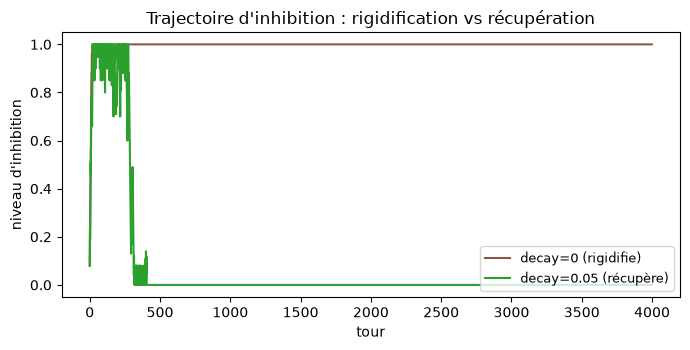

In [7]:
# Exercice 2 — stub (compléter)
# TODO: tracer la trajectoire d'inhibition pour growth=0.08, decay=0 vs decay=0.05.
fig, ax = plt.subplots(figsize=(7, 3.6))
for decay, color, label in [(0.0, "#8c564b", "decay=0 (rigidifie)"), (0.05, "#2ca02c", "decay=0.05 (récupère)")]:
    g = ii.InhibitedInventingGame(4, 1, temperature=0.6, invention_rate=0.1,
                                  inhibition_growth=0.08, inhibition_decay=decay,
                                  rng=np.random.default_rng(0))
    g.train(4000, anneal_to=0.15)
    ax.plot(g.inhibition_history, "-", color=color, label=label)
ax.set_xlabel("tour") ; ax.set_ylabel("niveau d'inhibition")
ax.set_title("Trajectoire d'inhibition : rigidification vs récupération")
ax.set_ylim(-0.05, 1.05) ; ax.legend(loc="lower right", fontsize=9)
fig.tight_layout() ; plt.show()

### Exercice 3 — Le seuil d'inhibition qui fige

À partir de quel `inhibition_growth` le vocabulaire final tombe-t-il sous
`n_states` ? Reproduisez le balayage de la §1 avec un pas plus fin autour du
seuil.

In [8]:
# Exercice 3 — stub (compléter)
# TODO: balayage fin autour du seuil de rigidification.
for g in [0.005, 0.01, 0.02, 0.04, 0.06]:
    vocabs = []
    for s in range(3):
        game = ii.InhibitedInventingGame(4, 1, temperature=0.6, invention_rate=0.1,
                                         inhibition_growth=g, rng=np.random.default_rng(s))
        game.train(4000, anneal_to=0.15)
        vocabs.append(game.final_vocab_size())
    print(f"growth={g:.3f} -> vocabulaire final moyen = {np.mean(vocabs):.2f}")

growth=0.005 -> vocabulaire final moyen = 4.00


growth=0.010 -> vocabulaire final moyen = 4.00


growth=0.020 -> vocabulaire final moyen = 3.33


growth=0.040 -> vocabulaire final moyen = 2.67


growth=0.060 -> vocabulaire final moyen = 2.00
